#  Task 4: Predicting Insurance Claim Amounts
### Objective: Estimate medical insurance charges using Linear Regression

---
**Skills Covered:**
-  Regression Modeling (Linear Regression)
-  Feature Correlation & Visualization (BMI, Age, Smoking Status)
-  Error Evaluation using MAE & RMSE

## Step 1: Install & Import Libraries

In [1]:
# Install libraries (needed on Google Colab)
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries imported successfully!')

All libraries imported successfully!


##  Step 2: Load the Dataset

> **Note:** Upload  `insurance.csv` file to Google Colab using the file upload option, OR run the cell below to download it directly from Kaggle's public mirror.

In [3]:
# ── Load dataset from uploaded file
df = pd.read_csv('/content/insurance (1).csv')

print(' Dataset loaded successfully!')
print(f' Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

 Dataset loaded successfully!
 Shape: 1338 rows × 7 columns


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


##  Step 3: Exploratory Data Analysis (EDA)

In [4]:
print('='*55)
print('         DATASET INFORMATION')
print('='*55)
print(f'\n Shape      : {df.shape}')
print(f' Columns    : {list(df.columns)}')
print(f'\n Data Types:')
print(df.dtypes)
print(f'\n Missing Values:')
print(df.isnull().sum())

         DATASET INFORMATION

 Shape      : (1338, 7)
 Columns    : ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

 Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

 Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:
print(' Statistical Summary:')
df.describe().round(2)

 Statistical Summary:


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [6]:
print(' Categorical Column Value Counts:\n')
for col in ['sex', 'smoker', 'region']:
    print(f'--- {col.upper()} ---')
    print(df[col].value_counts())
    print()

 Categorical Column Value Counts:

--- SEX ---
sex
male      676
female    662
Name: count, dtype: int64

--- SMOKER ---
smoker
no     1064
yes     274
Name: count, dtype: int64

--- REGION ---
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



## Step 4: Distribution of Insurance Charges (Target Variable)

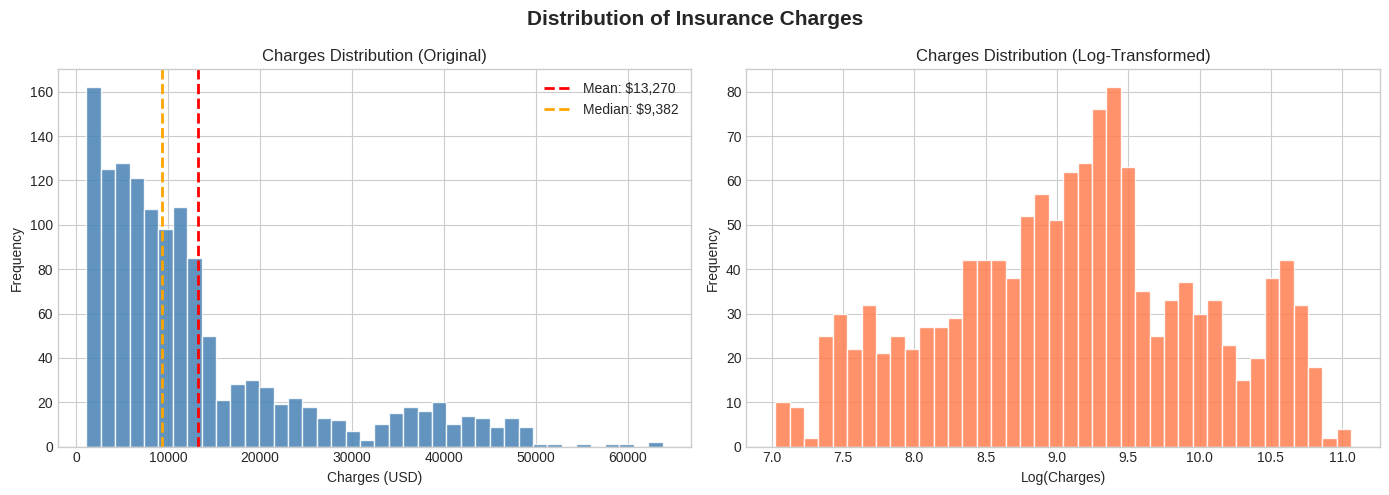

Charges are right-skewed. Mean = $13,270.42 | Median = $9,382.03


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Insurance Charges', fontsize=15, fontweight='bold')

# Histogram
axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Charges Distribution (Original)')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['charges'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["charges"].mean():,.0f}')
axes[0].axvline(df['charges'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: ${df["charges"].median():,.0f}')
axes[0].legend()

# Log-transformed
axes[1].hist(np.log1p(df['charges']), bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Charges Distribution (Log-Transformed)')
axes[1].set_xlabel('Log(Charges)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Charges are right-skewed. Mean = ${df["charges"].mean():,.2f} | Median = ${df["charges"].median():,.2f}')

## Step 5: Feature Visualizations — BMI, Age & Smoking Status vs Charges

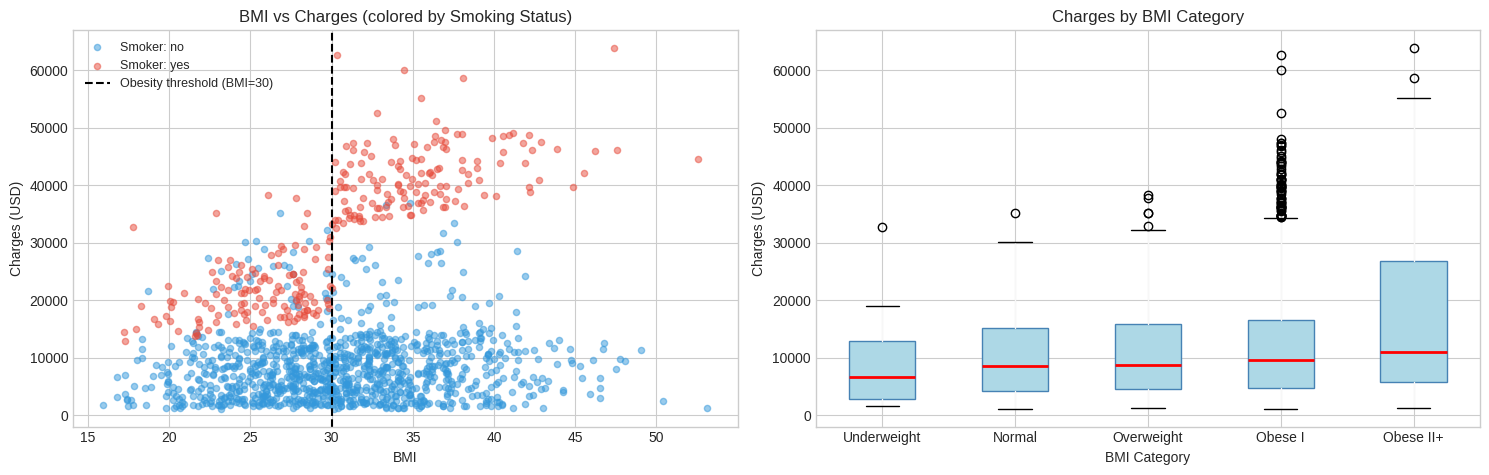

Mean Charges by BMI Group:
bmi_group
Underweight     $8,657.62
Normal         $10,435.44
Overweight     $10,997.80
Obese I        $14,429.42
Obese II+      $16,953.82
Name: charges, dtype: object


In [8]:
# ── 5.1: BMI vs Charges ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(' BMI Impact on Insurance Charges', fontsize=14, fontweight='bold')

# Scatter by smoker
colors = {'yes': '#e74c3c', 'no': '#3498db'}
for smoker_val, grp in df.groupby('smoker'):
    axes[0].scatter(grp['bmi'], grp['charges'],
                    c=colors[smoker_val], alpha=0.5, s=20,
                    label=f'Smoker: {smoker_val}')

# Add obesity threshold line
axes[0].axvline(x=30, color='black', linestyle='--', linewidth=1.5, label='Obesity threshold (BMI=30)')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Charges (USD)')
axes[0].set_title('BMI vs Charges (colored by Smoking Status)')
axes[0].legend(fontsize=9)

# BMI bins box plot
df['bmi_group'] = pd.cut(df['bmi'], bins=[0,18.5,25,30,35,100],
                          labels=['Underweight', 'Normal', 'Overweight', 'Obese I', 'Obese II+'])
df.boxplot(column='charges', by='bmi_group', ax=axes[1],
           patch_artist=True, notch=False,
           boxprops=dict(facecolor='lightblue', color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Charges by BMI Category')
axes[1].set_xlabel('BMI Category')
axes[1].set_ylabel('Charges (USD)')
plt.suptitle('')

plt.tight_layout()
plt.show()

# Mean charges per BMI group
print('Mean Charges by BMI Group:')
print(df.groupby('bmi_group', observed=True)['charges'].mean().apply(lambda x: f'${x:,.2f}'))

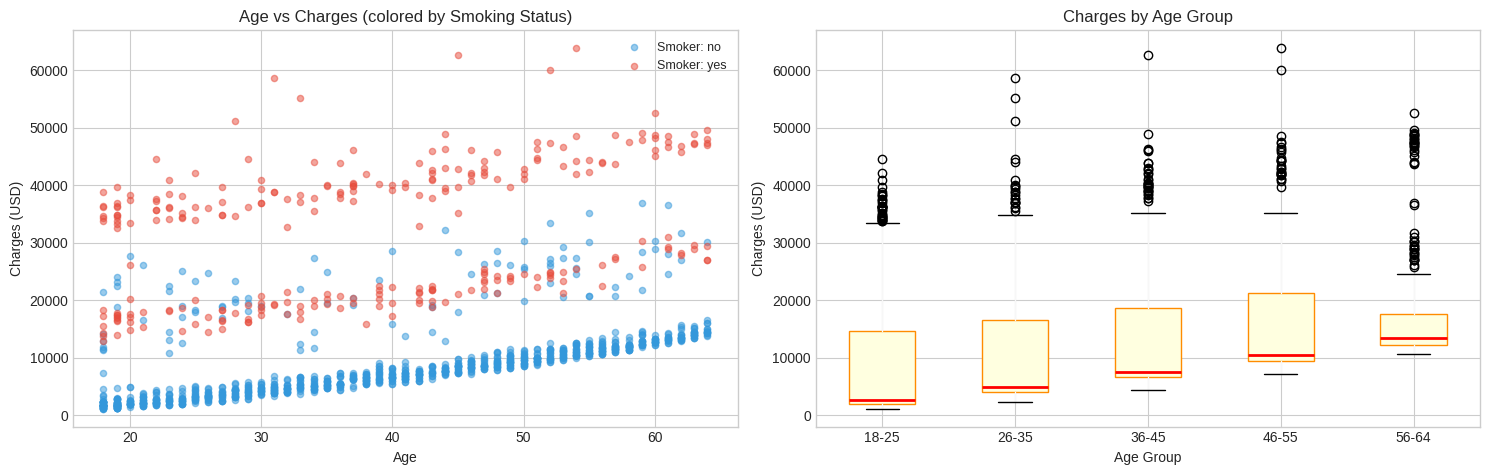

Mean Charges by Age Group:
age_group
18-25     $9,087.02
26-35    $10,495.16
36-45    $13,493.49
46-55    $15,986.90
56-64    $18,795.99
Name: charges, dtype: object


In [9]:
# ── 5.2: Age vs Charges ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(' Age Impact on Insurance Charges', fontsize=14, fontweight='bold')

# Scatter
for smoker_val, grp in df.groupby('smoker'):
    axes[0].scatter(grp['age'], grp['charges'],
                    c=colors[smoker_val], alpha=0.5, s=20,
                    label=f'Smoker: {smoker_val}')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges (USD)')
axes[0].set_title('Age vs Charges (colored by Smoking Status)')
axes[0].legend(fontsize=9)

# Age group box plot
df['age_group'] = pd.cut(df['age'], bins=[17,25,35,45,55,65],
                          labels=['18-25','26-35','36-45','46-55','56-64'])
df.boxplot(column='charges', by='age_group', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='lightyellow', color='darkorange'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Charges by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Charges (USD)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('Mean Charges by Age Group:')
print(df.groupby('age_group', observed=True)['charges'].mean().apply(lambda x: f'${x:,.2f}'))

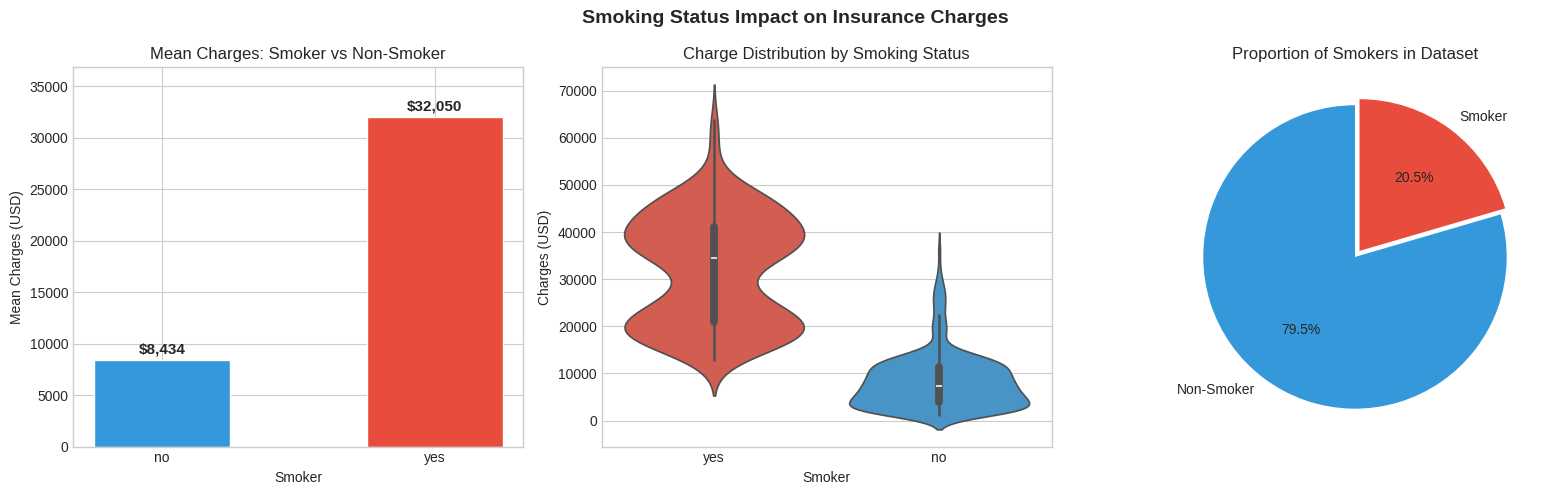

 Key Finding: Smokers pay 3.8x MORE than non-smokers on average!
 Non-Smoker avg: $8,434.27
 Smoker avg    : $32,050.23


In [10]:
# ── 5.3: Smoking Status vs Charges ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Smoking Status Impact on Insurance Charges', fontsize=14, fontweight='bold')

# Bar chart: mean charges
mean_charges = df.groupby('smoker')['charges'].mean()
bar_colors = ['#3498db', '#e74c3c']
bars = axes[0].bar(mean_charges.index, mean_charges.values, color=bar_colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, mean_charges.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'${val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Mean Charges: Smoker vs Non-Smoker')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Mean Charges (USD)')
axes[0].set_ylim(0, max(mean_charges.values) * 1.15)

# Violin plot
smoker_map = {'yes': 1, 'no': 0}
df_v = df.copy()
df_v['smoker_num'] = df_v['smoker'].map(smoker_map)
sns.violinplot(data=df, x='smoker', y='charges', ax=axes[1],
               palette={'yes': '#e74c3c', 'no': '#3498db'}, inner='box')
axes[1].set_title('Charge Distribution by Smoking Status')
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Charges (USD)')

# Pie chart: proportion
smoker_counts = df['smoker'].value_counts()
axes[2].pie(smoker_counts.values, labels=['Non-Smoker', 'Smoker'],
            colors=['#3498db', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, explode=[0, 0.05])
axes[2].set_title('Proportion of Smokers in Dataset')

plt.tight_layout()
plt.show()

ratio = mean_charges['yes'] / mean_charges['no']
print(f' Key Finding: Smokers pay {ratio:.1f}x MORE than non-smokers on average!')
print(f' Non-Smoker avg: ${mean_charges["no"]:,.2f}')
print(f' Smoker avg    : ${mean_charges["yes"]:,.2f}')

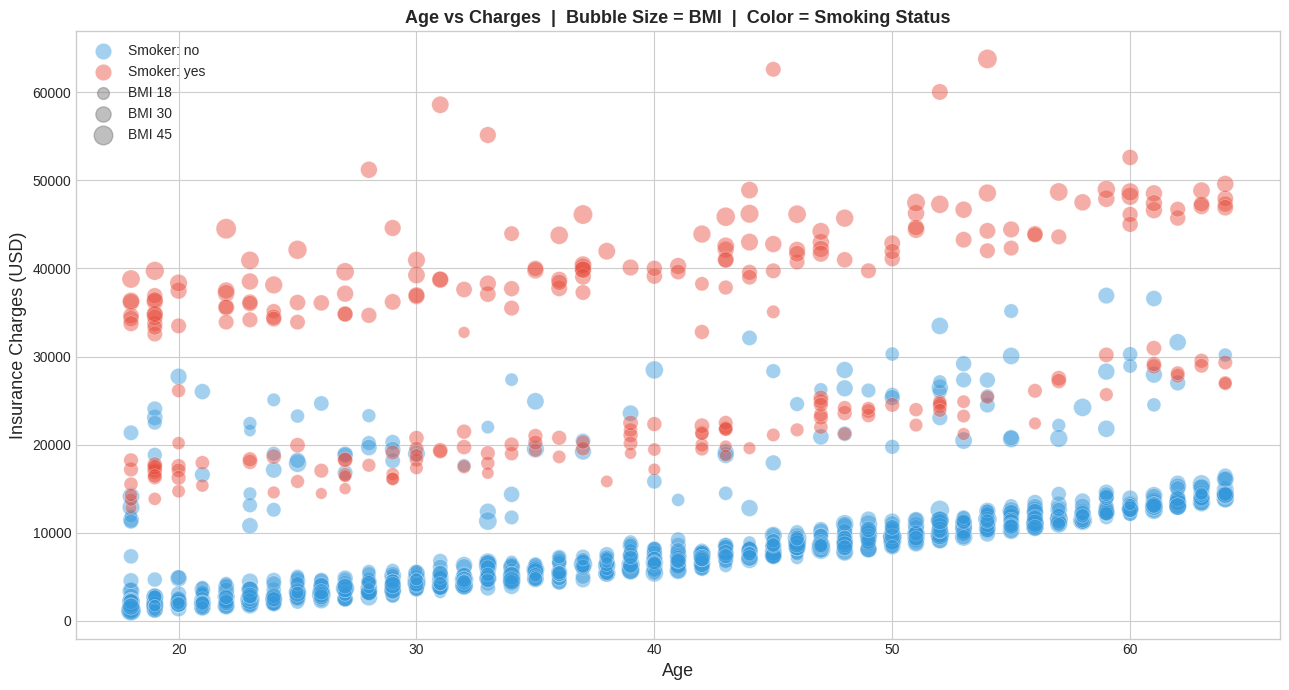

In [11]:
# ── 5.4: Combined — Age, BMI, Smoker, Charges (Bubble Plot) ───────────────
fig, ax = plt.subplots(figsize=(13, 7))

for smoker_val, grp in df.groupby('smoker'):
    sc = ax.scatter(
        grp['age'], grp['charges'],
        s=grp['bmi'] * 4,
        c=colors[smoker_val], alpha=0.45,
        label=f'Smoker: {smoker_val}',
        edgecolors='white', linewidths=0.4
    )

ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Insurance Charges (USD)', fontsize=13)
ax.set_title('Age vs Charges  |  Bubble Size = BMI  |  Color = Smoking Status',
             fontsize=13, fontweight='bold')

# Legend for bubble size
for bmi_val, label in [(18, 'BMI 18'), (30, 'BMI 30'), (45, 'BMI 45')]:
    ax.scatter([], [], s=bmi_val*4, c='gray', alpha=0.5, label=label)

ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

##  Step 6: Correlation Heatmap

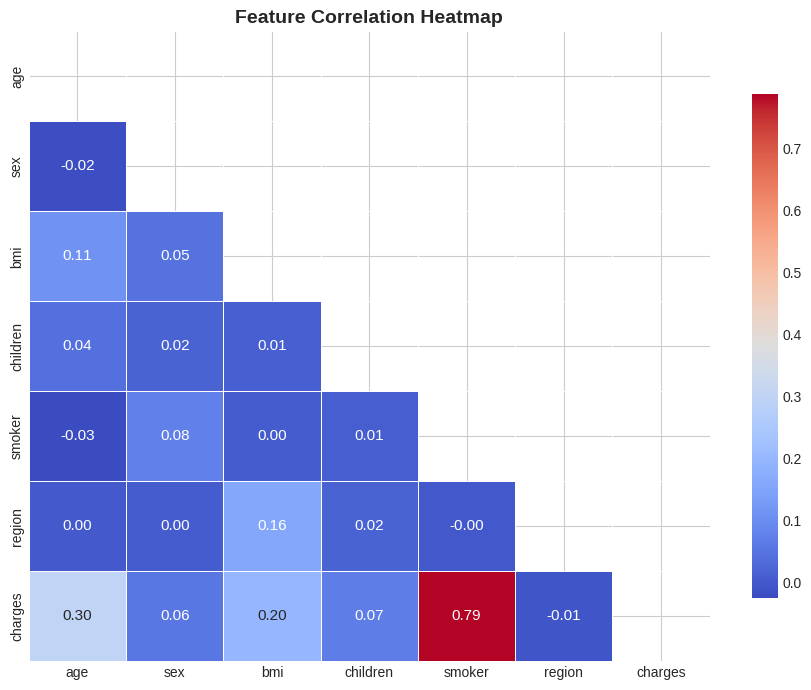

 Correlation with Charges:
charges      1.0000
smoker       0.7873
age          0.2990
bmi          0.1983
children     0.0680
sex          0.0573
region      -0.0062
Name: charges, dtype: object


In [12]:
# Encode categorical columns for correlation
df_encoded = df.copy()
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Drop temporary grouping columns
df_encoded = df_encoded.drop(columns=['bmi_group', 'age_group'], errors='ignore')

corr = df_encoded.corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 11})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(' Correlation with Charges:')
print(corr['charges'].sort_values(ascending=False).apply(lambda x: f'{x:.4f}'))

##  Step 7: Data Preprocessing & Feature Engineering

In [13]:
# Work with fresh copy
df_model = df[['age','sex','bmi','children','smoker','region','charges']].copy()

# Encode categorical columns
label_cols = ['sex', 'smoker', 'region']
encoders = {}
for col in label_cols:
    enc = LabelEncoder()
    df_model[col] = enc.fit_transform(df_model[col])
    encoders[col] = enc
    print(f' {col}: {dict(zip(enc.classes_, enc.transform(enc.classes_)))}')

print('\n Processed DataFrame (first 5 rows):')
df_model.head()

 sex: {'female': np.int64(0), 'male': np.int64(1)}
 smoker: {'no': np.int64(0), 'yes': np.int64(1)}
 region: {'northeast': np.int64(0), 'northwest': np.int64(1), 'southeast': np.int64(2), 'southwest': np.int64(3)}

 Processed DataFrame (first 5 rows):


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## Step 8: Train the Linear Regression Model

In [14]:
# ── Define Features & Target ──────────────────────────────────────────────
X = df_model.drop('charges', axis=1)
y = df_model['charges']

# ── Train/Test Split (80/20) ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f' Testing  samples : {X_test.shape[0]}')

# ── Train Model ───────────────────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

print('\n Model trained successfully!')

# ── Model Coefficients ────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(f'\n Intercept: ${model.intercept_:,.2f}')
print('\n Feature Coefficients:')
print(coef_df.to_string(index=False))

Training samples : 1070
 Testing  samples : 268

 Model trained successfully!

 Intercept: $-11,946.61

 Feature Coefficients:
 Feature  Coefficient
  smoker 23647.818096
children   425.091456
     bmi   335.781491
     age   257.056264
     sex   -18.791457
  region  -271.284266


##  Step 9: Model Evaluation — MAE & RMSE

In [15]:
# ── Predictions
y_pred = model.predict(X_test)

# ── Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print('='*50)
print('       MODEL PERFORMANCE METRICS')
print('='*50)
print(f'  MAE  (Mean Absolute Error)  : ${mae:>10,.2f}')
print(f'  RMSE (Root Mean Sq. Error)  : ${rmse:>10,.2f}')
print(f'  R²   (R-squared Score)      : {r2:>12.4f}')
print(f'  MAPE (Mean Abs % Error)     : {mape:>11.2f}%')
print('='*50)

print('\n Interpretation:')
print(f'   • On average, predictions are off by ${mae:,.2f} (MAE)')
print(f'   • RMSE of ${rmse:,.2f} penalizes larger errors more')
print(f'   • R² of {r2:.2f} means the model explains {r2*100:.1f}% of variance in charges')

       MODEL PERFORMANCE METRICS
  MAE  (Mean Absolute Error)  : $  4,186.51
  RMSE (Root Mean Sq. Error)  : $  5,799.59
  R²   (R-squared Score)      :       0.7833
  MAPE (Mean Abs % Error)     :       47.09%

 Interpretation:
   • On average, predictions are off by $4,186.51 (MAE)
   • RMSE of $5,799.59 penalizes larger errors more
   • R² of 0.78 means the model explains 78.3% of variance in charges


## Step 10: Visualizing Model Performance

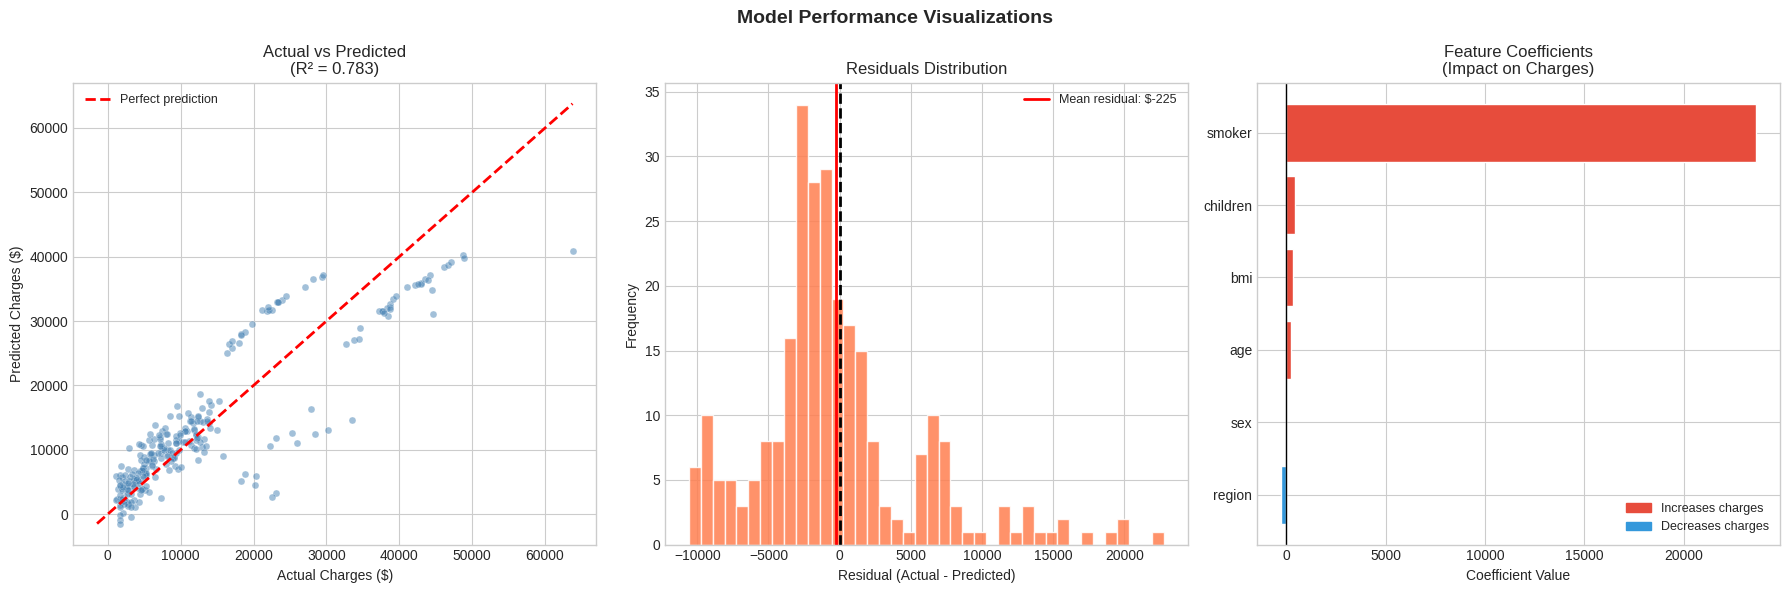

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Visualizations', fontsize=14, fontweight='bold')

# ── Plot 1: Actual vs Predicted ───────────────────────────────────────────
axes[0].scatter(y_test, y_pred, alpha=0.5, s=25, color='steelblue', edgecolors='white', linewidths=0.3)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Charges ($)')
axes[0].set_ylabel('Predicted Charges ($)')
axes[0].set_title(f'Actual vs Predicted\n(R² = {r2:.3f})')
axes[0].legend(fontsize=9)

# ── Plot 2: Residuals Distribution ───────────────────────────────────────
residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1].axvline(residuals.mean(), color='red', linestyle='-', linewidth=2,
                label=f'Mean residual: ${residuals.mean():,.0f}')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')
axes[1].legend(fontsize=9)

# ── Plot 3: Feature Coefficients (Impact) ────────────────────────────────
coef_sorted = coef_df.sort_values('Coefficient')
bar_colors_coef = ['#e74c3c' if c > 0 else '#3498db' for c in coef_sorted['Coefficient']]
axes[2].barh(coef_sorted['Feature'], coef_sorted['Coefficient'],
             color=bar_colors_coef, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set_xlabel('Coefficient Value')
axes[2].set_title('Feature Coefficients\n(Impact on Charges)')
red_patch  = mpatches.Patch(color='#e74c3c', label='Increases charges')
blue_patch = mpatches.Patch(color='#3498db', label='Decreases charges')
axes[2].legend(handles=[red_patch, blue_patch], fontsize=9)

plt.tight_layout()
plt.show()

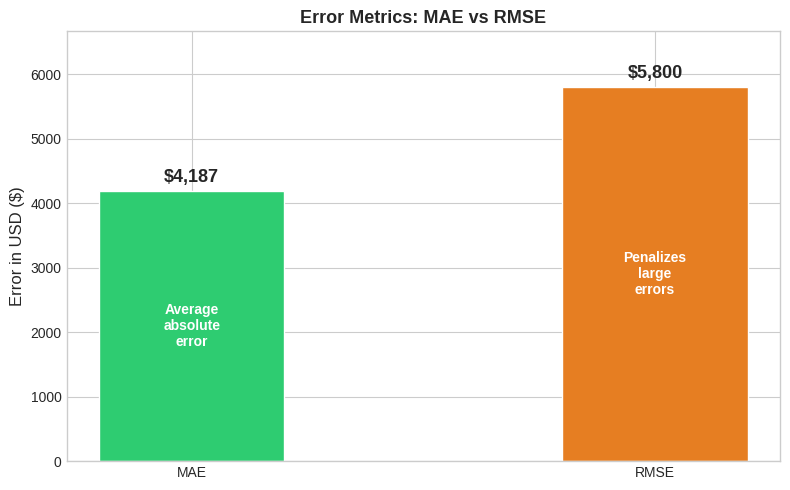

In [17]:
# ── Metric Summary Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))

metrics  = ['MAE', 'RMSE']
values   = [mae, rmse]
bar_cols = ['#2ecc71', '#e67e22']

bars = ax.bar(metrics, values, color=bar_cols, width=0.4, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Error in USD ($)', fontsize=12)
ax.set_title('Error Metrics: MAE vs RMSE', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(values) * 1.15)

# Annotations
ax.text(0, mae/2, 'Average\nabsolute\nerror', ha='center', va='center',
        color='white', fontsize=10, fontweight='bold')
ax.text(1, rmse/2, 'Penalizes\nlarge\nerrors', ha='center', va='center',
        color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

##  Step 11: Predict for a New Person

In [18]:
# ── Example: Predict charge for a specific person ─────────────────────────
# sex    : female=0, male=1
# smoker : no=0, yes=1
# region : northeast=0, northwest=1, southeast=2, southwest=3

new_person = pd.DataFrame({
    'age'      : [35],
    'sex'      : [1],       # male
    'bmi'      : [28.5],
    'children' : [2],
    'smoker'   : [0],       # non-smoker
    'region'   : [2]        # southeast
})

predicted_charge = model.predict(new_person)[0]

print('='*50)
print('       INSURANCE CHARGE PREDICTION')
print('='*50)
print(f'  Person Profile:')
print(f'    Age      : 35 years')
print(f'    Sex      : Male')
print(f'    BMI      : 28.5')
print(f'    Children : 2')
print(f'    Smoker   : No')
print(f'    Region   : Southeast')
print('-'*50)
print(f'   Predicted Charge: ${predicted_charge:,.2f}')
print('='*50)

       INSURANCE CHARGE PREDICTION
  Person Profile:
    Age      : 35 years
    Sex      : Male
    BMI      : 28.5
    Children : 2
    Smoker   : No
    Region   : Southeast
--------------------------------------------------
   Predicted Charge: $6,908.96


## Step 12: Final Summary & Key Findings

In [19]:
print('='*60)
print('          TASK 4 — FINAL SUMMARY')
print('='*60)
print()
print(' DATASET')
print(f'   • 1,338 records | 6 features | Target: charges')
print()
print(' KEY VISUALIZATIONS')
print('   • BMI vs Charges  → Obese + smokers pay the most')
print('   • Age vs Charges  → Charges rise linearly with age')
print(f'   • Smoker Impact   → Smokers pay ~{ratio:.1f}x more than non-smokers')
print()
print(' TOP CORRELATIONS WITH CHARGES')
top_corr = corr['charges'].drop('charges').abs().sort_values(ascending=False)
for feat, val in top_corr.items():
    bar = '█' * int(val * 20)
    print(f'   {feat:<12} {bar} {val:.3f}')
print()
print(' MODEL: Linear Regression (Train 80% | Test 20%)')
print()
print(' PERFORMANCE METRICS')
print(f'   • MAE  : ${mae:,.2f}  (avg. error per prediction)')
print(f'   • RMSE : ${rmse:,.2f}  (penalizes large errors)')
print(f'   • R²   : {r2:.4f}   ({r2*100:.1f}% variance explained)')
print()
print(' CONCLUSION')
print('   Smoking status is the STRONGEST predictor of charges.')
print('   Age and BMI also significantly increase costs.')
print('   Linear Regression gives a solid baseline model.')
print('='*60)

          TASK 4 — FINAL SUMMARY

 DATASET
   • 1,338 records | 6 features | Target: charges

 KEY VISUALIZATIONS
   • BMI vs Charges  → Obese + smokers pay the most
   • Age vs Charges  → Charges rise linearly with age
   • Smoker Impact   → Smokers pay ~3.8x more than non-smokers

 TOP CORRELATIONS WITH CHARGES
   smoker       ███████████████ 0.787
   age          █████ 0.299
   bmi          ███ 0.198
   children     █ 0.068
   sex          █ 0.057
   region        0.006

 MODEL: Linear Regression (Train 80% | Test 20%)

 PERFORMANCE METRICS
   • MAE  : $4,186.51  (avg. error per prediction)
   • RMSE : $5,799.59  (penalizes large errors)
   • R²   : 0.7833   (78.3% variance explained)

 CONCLUSION
   Smoking status is the STRONGEST predictor of charges.
   Age and BMI also significantly increase costs.
   Linear Regression gives a solid baseline model.
